In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("heart_disease_uci.csv")
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [3]:
df.isnull().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

In [4]:
df.columns

Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 156.4+ KB


In [6]:
df.sample(18)

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
146,147,57,Male,Cleveland,asymptomatic,165.0,289.0,True,lv hypertrophy,124.0,False,1.0,flat,3.0,reversable defect,4
888,889,64,Male,VA Long Beach,asymptomatic,NaN,244.0,True,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,2
904,905,57,Male,VA Long Beach,asymptomatic,130.0,207.0,False,st-t abnormality,96.0,True,1.0,flat,NaN,NaN,0
276,277,66,Female,Cleveland,non-anginal,146.0,278.0,False,lv hypertrophy,152.0,False,0.0,flat,1.0,normal,0
648,649,55,Male,Switzerland,atypical angina,140.0,0.0,NaN,st-t abnormality,150.0,False,0.2,upsloping,NaN,NaN,0
256,257,67,Female,Cleveland,asymptomatic,106.0,223.0,False,normal,142.0,False,0.3,upsloping,2.0,normal,0
184,185,60,Female,Cleveland,asymptomatic,158.0,305.0,False,lv hypertrophy,161.0,False,0.0,upsloping,0.0,normal,1
537,538,48,Male,Hungary,asymptomatic,160.0,193.0,False,normal,102.0,True,3.0,flat,NaN,NaN,1
103,104,71,Female,Cleveland,non-anginal,110.0,265.0,True,lv hypertrophy,130.0,False,0.0,upsloping,1.0,normal,0
97,98,60,Female,Cleveland,asymptomatic,150.0,258.0,False,lv hypertrophy,157.0,False,2.6,flat,2.0,reversable defect,3


## droping the useless /highly empty columns 

In [7]:
cols_to_drop = ['id', 'dataset', 'slope', 'ca', 'thal']
df_clean = df.drop(columns=cols_to_drop)

In [8]:
df_clean['num'] = df_clean['num'].apply(lambda x: 1 if x > 0 else 0)

In [9]:
df_clean.sample(15)

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,num
66,60,Male,non-anginal,140.0,185.0,False,lv hypertrophy,155.0,False,3.0,1
285,58,Male,asymptomatic,114.0,318.0,False,st-t abnormality,140.0,False,4.4,1
669,59,Male,non-anginal,125.0,0.0,NaN,normal,175.0,False,2.6,1
173,62,Female,asymptomatic,140.0,394.0,False,lv hypertrophy,157.0,False,1.2,0
519,54,Male,asymptomatic,125.0,216.0,False,normal,140.0,False,0.0,1
863,64,Male,asymptomatic,134.0,273.0,False,normal,102.0,True,4.0,1
70,65,Female,non-anginal,155.0,269.0,False,normal,148.0,False,0.8,0
707,65,Male,asymptomatic,160.0,0.0,True,st-t abnormality,122.0,False,NaN,1
435,53,Female,atypical angina,140.0,216.0,False,normal,142.0,True,2.0,0
197,45,Female,asymptomatic,138.0,236.0,False,lv hypertrophy,152.0,True,0.2,0


In [10]:
df_clean.isnull().sum()

age          0
sex          0
cp           0
trestbps    59
chol        30
fbs         90
restecg      2
thalch      55
exang       55
oldpeak     62
num          0
dtype: int64

## fill missing values 

## Fill numeric columns with the median of their age group

In [11]:

df_clean['chol'] = df_clean['chol'].replace(0, np.nan)
numeric_cols = ['chol', 'trestbps', 'thalch', 'oldpeak']
df_clean[numeric_cols] = df_clean.groupby('sex')[numeric_cols].transform(lambda x: x.fillna(x.median()))

##  Fill categorical/boolean with mode

In [12]:
cate_columns=['fbs','exang','restecg']
df_clean[cate_columns] = df_clean.groupby('sex')[cate_columns].transform(lambda x: x.fillna(x.mode()[0]))

In [13]:
df_clean.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
num         0
dtype: int64

## Plot Distributions (Age, Blood Pressure, Cholesterol)

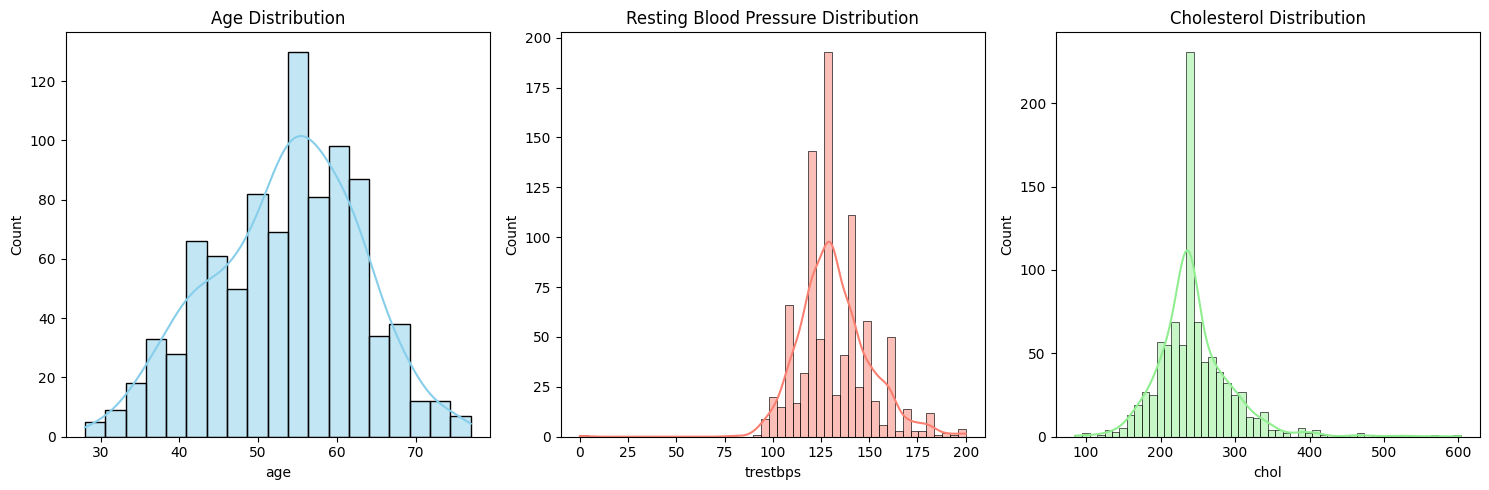

In [14]:
# Set up the plotting area
plt.figure(figsize=(15, 5))

# Age Distribution
plt.subplot(1, 3, 1)
sns.histplot(df_clean['age'], kde=True, color='skyblue')
plt.title('Age Distribution')

# Blood Pressure (trestbps) Distribution
plt.subplot(1, 3, 2)
sns.histplot(df_clean['trestbps'], kde=True, color='salmon')
plt.title('Resting Blood Pressure Distribution')

# Cholesterol Distribution
plt.subplot(1, 3, 3)
sns.histplot(df_clean['chol'], kde=True, color='lightgreen')
plt.title('Cholesterol Distribution')

plt.tight_layout()
plt.show()

## Class Imbalance Check

num
1    509
0    411
Name: count, dtype: int64


C:\Users\Tushar pradhan\AppData\Local\Temp\ipykernel_13776\3602547806.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='num', palette='Set2')


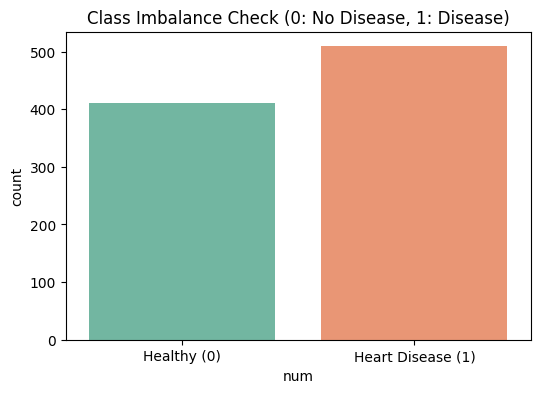

In [15]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_clean, x='num', palette='Set2')
plt.title('Class Imbalance Check (0: No Disease, 1: Disease)')
plt.xticks(ticks=[0, 1], labels=['Healthy (0)', 'Heart Disease (1)'])

# Print the exact value counts above the plot
print(df_clean['num'].value_counts())
plt.show()

## Correlation Heatmap

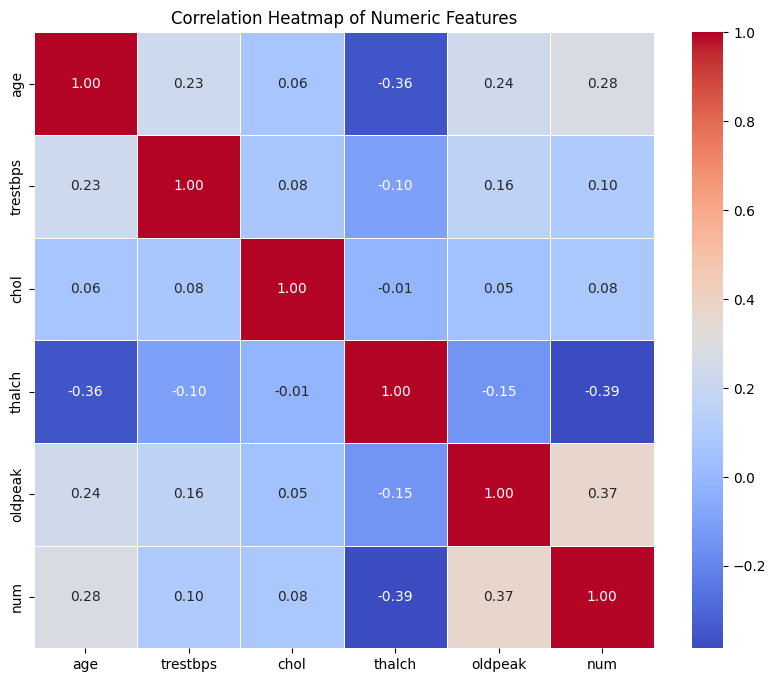

In [16]:
plt.figure(figsize=(10, 8))

# Select only the numeric columns for correlation
numeric_features = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'num']
corr_matrix = df_clean[numeric_features].corr()

# Draw the heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

In [17]:
df_clean.sample(30)

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,num
814,60,Male,asymptomatic,130.0,195.0,False,normal,135.0,False,0.6,0
33,59,Male,asymptomatic,135.0,234.0,False,normal,161.0,False,0.5,0
66,60,Male,non-anginal,140.0,185.0,False,lv hypertrophy,155.0,False,3.0,1
55,54,Male,asymptomatic,124.0,266.0,False,lv hypertrophy,109.0,True,2.2,1
770,55,Male,non-anginal,120.0,236.5,False,st-t abnormality,125.0,True,2.5,1
309,32,Male,atypical angina,110.0,225.0,False,normal,184.0,False,0.0,0
35,42,Male,asymptomatic,140.0,226.0,False,normal,178.0,False,0.0,0
457,54,Male,non-anginal,150.0,236.5,False,normal,122.0,False,0.0,0
691,62,Male,typical angina,120.0,236.5,False,lv hypertrophy,134.0,False,-0.8,1
313,34,Male,atypical angina,150.0,214.0,False,st-t abnormality,168.0,False,0.0,0


## Encodeing  cleaned dataset 

In [18]:
# 1. Remap the binary columns on clean data freshly
df_clean['sex'] = df_clean['sex'].map({'Male': 1, 'Female': 0})
df_clean['exang'] = df_clean['exang'].map({True: 1, False: 0})
df_clean['fbs'] = df_clean['fbs'].astype(int)

# 2. One-hot encode multi-category columns safely
df_encoded = pd.get_dummies(df_clean, columns=['cp', 'restecg'], drop_first=True, dtype=int)

# 3. Scale ONLY the continuous numeric features inside df_encoded
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scale_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']

# Notice we fit_transform on df_encoded's own columns now to avoid any NaN misalignment!
df_encoded[scale_cols] = scaler.fit_transform(df_encoded[scale_cols])

# 4. Verify that all NaNs are 100% gone
print(df_encoded.isnull().sum())

age                         0
sex                         0
trestbps                    0
chol                        0
fbs                         0
thalch                      0
exang                       0
oldpeak                     0
num                         0
cp_atypical angina          0
cp_non-anginal              0
cp_typical angina           0
restecg_normal              0
restecg_st-t abnormality    0
dtype: int64


## Feature Scaling (Crucial Final Step)

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scale_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']


df_encoded[scale_cols] = scaler.fit_transform(df_clean[scale_cols])

In [20]:
df_encoded.sample(17)

,age,sex,trestbps,chol,fbs,thalch,exang,oldpeak,num,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality
365,-1.115855,0,-0.650479,0.081047,0,1.534445,0,-0.813882,0,1,0,0,0,1
393,-0.585045,0,-0.108217,1.219275,0,0.500182,0,1.080303,0,1,0,0,0,1
462,0.158089,1,-0.650479,0.216091,1,-0.016949,0,-0.813882,0,1,0,0,1,0
576,0.264251,1,2.060831,2.762636,0,-0.613639,1,1.080303,1,0,0,0,0,1
490,0.901224,1,0.434045,0.505471,0,0.579741,0,0.133211,0,1,0,0,1,0
221,0.051927,0,-1.301193,0.428303,0,1.176431,0,-0.813882,0,0,1,0,0,0
523,0.476575,1,-0.108217,-0.613465,0,0.102389,0,-0.813882,1,0,1,0,0,1
225,-2.071314,0,-0.758931,-0.671341,0,2.170914,0,-0.150917,0,1,0,0,1,0
78,-0.585045,1,-0.108217,0.003879,0,1.693562,0,-0.624463,0,1,0,0,0,0
63,0.051927,0,0.162914,1.142107,1,1.295769,0,-0.813882,0,0,1,0,1,0


## importing all model 

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression 
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

## data split in test and train data

In [22]:
x=df_encoded.drop(columns=['num'])
y=df_encoded['num']
x_train,x_test,y_train,y_test= train_test_split(
    x,y, test_size=0.2,random_state=42,stratify=y
)

In [23]:
df_encoded.isnull().sum()

age                         0
sex                         0
trestbps                    0
chol                        0
fbs                         0
thalch                      0
exang                       0
oldpeak                     0
num                         0
cp_atypical angina          0
cp_non-anginal              0
cp_typical angina           0
restecg_normal              0
restecg_st-t abnormality    0
dtype: int64

In [24]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

# Initialize the models you imported
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss')
}

# Loop through, train, and evaluate each model on the test data
for name, model in models.items():
    # Train the model
    model.fit(x_train, y_train)
    
    # Get hard class predictions (0 or 1) for Accuracy, F1, and Confusion Matrix
    y_pred = model.predict(x_test)
    
    # Get probability scores for the positive class (1) required for ROC-AUC
    y_prob = model.predict_proba(x_test)[:, 1]
    
    # Print metrics
    print(f"\n================ {name} ================")
    print(f"Accuracy:      {accuracy_score(y_test, y_pred):.4f}")
    print(f"F1-Score:      {f1_score(y_test, y_pred):.4f}")
    print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))


================ Logistic Regression ================
Accuracy:      0.7935
F1-Score:      0.8208
ROC-AUC Score: 0.8899
Confusion Matrix:
[[59 23]
 [15 87]]

================ Random Forest ================
Accuracy:      0.8152
F1-Score:      0.8381
ROC-AUC Score: 0.9029
Confusion Matrix:
[[62 20]
 [14 88]]

================ XGBoost ================
Accuracy:      0.8315
F1-Score:      0.8517
ROC-AUC Score: 0.8724
Confusion Matrix:
[[64 18]
 [13 89]]


In [25]:
import os
import joblib
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

# 1. Define the parameter grid for XGBoost
# We tune depth, learning speed, and the number of trees
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 200, 300],
    'subsample': [0.8, 1.0]
}

# 2. Initialize GridSearchCV 
# cv=5 means 5-fold cross-validation; scoring='f1' optimizes for the best balance of precision/recall
grid_search = GridSearchCV(
    estimator=XGBClassifier(random_state=42, eval_metric='logloss'),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,  # Uses all available CPU cores to speed it up
    verbose=1
)

# 3. Run the grid search on your training data
print("Starting Hyperparameter Tuning...")
grid_search.fit(x_train, y_train)

# 4. Extract the best model configuration
best_xgb_model = grid_search.best_estimator_
print(f"\nBest Parameters Found: {grid_search.best_params_}")

# 5. Evaluate the optimized model on your test split
y_pred_best = best_xgb_model.predict(x_test)
y_prob_best = best_xgb_model.predict_proba(x_test)[:, 1]

print("\n================ Optimized XGBoost ================")
print(f"Accuracy:      {accuracy_score(y_test, y_pred_best):.4f}")
print(f"F1-Score:      {f1_score(y_test, y_pred_best):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_best):.4f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))

# 6. Create the 'models' folder if it doesn't exist yet, then save the model
os.makedirs('models', exist_ok=True)
joblib.dump(best_xgb_model, 'models/xgb_model.pkl')
print("\nModel successfully tuned and saved to 'models/xgb_model.pkl'!")

Starting Hyperparameter Tuning...
Fitting 5 folds for each of 54 candidates, totalling 270 fits

Best Parameters Found: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 300, 'subsample': 1.0}

================ Optimized XGBoost ================
Accuracy:      0.7989
F1-Score:      0.8279
ROC-AUC Score: 0.8935
Confusion Matrix:
[[58 24]
 [13 89]]

Model successfully tuned and saved to 'models/xgb_model.pkl'!


In [26]:

!pip install shap

SHAP values calculated successfully!


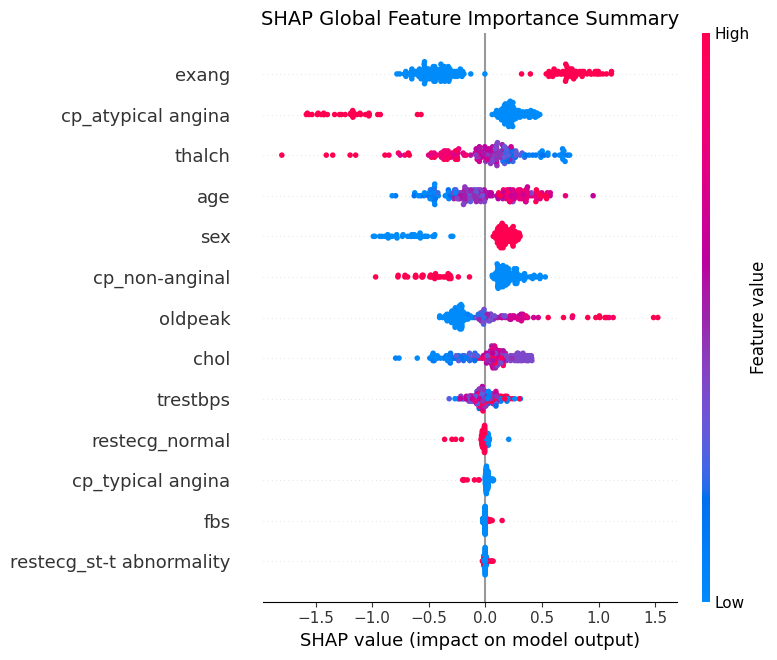

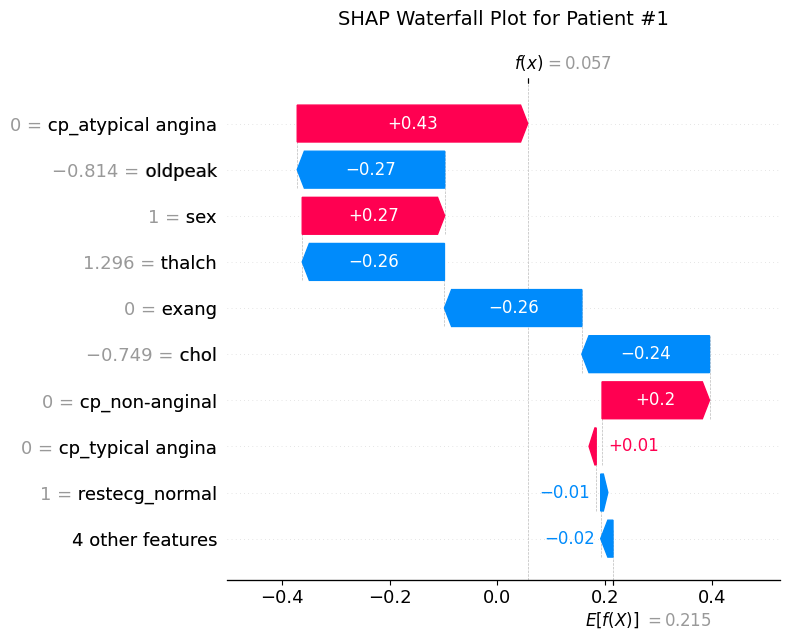

Successfully generated and saved 'shap_values.csv' for Power BI tracking!


In [27]:
import shap
import pandas as pd
import matplotlib.pyplot as plt

# 1. Initialize the SHAP Explainer using your tuned XGBoost model
# We use TreeExplainer because it is optimized for tree ensembles like XGBoost
explainer = shap.TreeExplainer(best_xgb_model)

# 2. Calculate SHAP values for your test dataset
# This computes the exact contribution of every feature for every patient in x_test
shap_values = explainer(x_test)

print("SHAP values calculated successfully!")

# --- VISUALIZATION 1: Summary Plot (Global Importance) ---
plt.figure(figsize=(10, 6))
plt.title("SHAP Global Feature Importance Summary", fontsize=14)
shap.summary_plot(shap_values, x_test, show=False)
plt.tight_layout()
plt.show()

# --- VISUALIZATION 2: Waterfall Plot (Single Patient Deep-Dive) ---
# We select the very first patient index [0] in your test set to explain their specific risk profile
plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_values[0], show=False)
plt.title("SHAP Waterfall Plot for Patient #1", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

# --- VISUALIZATION 3: Force Plot (Visual Push/Pull) ---
# Force plots require loading the JavaScript library into the Jupyter notebook interface
shap.initjs()
# Plotting the visual push/pull interactive layout for the first patient
shap.plots.force(shap_values[0])

# --- STEP 3: Export SHAP values to CSV for Power BI ---
# Convert the raw SHAP matrix array into a readable DataFrame matching x_test's columns
shap_df = pd.DataFrame(shap_values.values, columns=x_test.columns)

# Append suffix '_shap' to columns so you can match them against your raw values in Power BI
shap_df = shap_df.add_suffix('_shap')

# Include the true patient identifier target and raw values back in for mapping inside BI
power_bi_export = pd.concat([x_test.reset_index(drop=True), shap_df], axis=1)
power_bi_export['true_target'] = y_test.values

# Save to your working workspace directory
power_bi_export.to_csv('shap_values.csv', index=False)
print("Successfully generated and saved 'shap_values.csv' for Power BI tracking!")

In [28]:
import os
import pandas as pd
import shap
import joblib
from sklearn.metrics import confusion_matrix, roc_auc_score, accuracy_score
import numpy as np

# 1. CRITICAL: Create the 'powerbi' folder automatically if it doesn't exist
os.makedirs('powerbi', exist_ok=True)

# ── 1. Save cleaned_data.csv ──────────────────────────────
df_clean.to_csv('powerbi/cleaned_data.csv', index=False)

# ── 2. Save shap_values.csv ───────────────────────────────
best_model = joblib.load('models/xgb_model.pkl')

# Fixed: Changed X_test to x_test to match your training cell
explainer = shap.Explainer(best_model, x_test)
shap_values = explainer(x_test)

# Convert SHAP values array to DataFrame
shap_df = pd.DataFrame(shap_values.values, columns=x_test.columns)

# Build the feature importance mapping matrix
feature_importance = pd.DataFrame({
    'Feature': x_test.columns, 
    'SHAP_Value': np.abs(shap_values.values).mean(axis=0)
}).sort_values('SHAP_Value', ascending=False)

feature_importance.to_csv('powerbi/shap_values.csv', index=False)

# ── 3. Save model_metrics.csv ─────────────────────────────
# Fixed: Changed X_test/y_test to lowercase x_test/y_test
y_pred = best_model.predict(x_test)
y_proba = best_model.predict_proba(x_test)[:, 1]
cm = confusion_matrix(y_test, y_pred)

metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'ROC_AUC', 'Precision', 'Recall', 'TP', 'TN', 'FP', 'FN'],
    'Value': [
        round(accuracy_score(y_test, y_pred), 3),
        round(roc_auc_score(y_test, y_proba), 3),
        round(cm[1, 1] / (cm[1, 1] + cm[0, 1]), 3),
        round(cm[1, 1] / (cm[1, 1] + cm[1, 0]), 3),
        cm[1, 1],
        cm[0, 0],
        cm[0, 1],
        cm[1, 0]
    ]
})

metrics_df.to_csv('powerbi/model_metrics.csv', index=False)

print("All CSVs exported to /powerbi folder successfully! ✓")

All CSVs exported to /powerbi folder successfully! ✓
